# **決定木の実装例（その3）**

ここでは，第3章で整理した決定木の理論とアルゴリズムをデータ分析問題に適用してみます．分割基準や木の深さ，リーフノードの制約といった主要なハイパーパラメータが，モデルの振舞いにどのような影響を与えるのかも確認します．

## **回帰問題（コンクリートの圧縮強度予測）**

ここでは，コンクリートの圧縮強度予測という現実的な工学的課題を題材とし，回帰木モデルの適用事例を解説します．

#### **■Step 0. ライブラリのインポート**

まず，Colab上で必要なライブラリをインストールし，次に必要なライブラリを一括してインポートします．

In [18]:
!pip install ucimlrepo
'''
I. Yeh. "Concrete Compressive Strength,"
UCI Machine Learning Repository, 1998.
[Online]. Available: https://doi.org/10.24432/C5PK67.
'''
# https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # ペアプロット作成に使用
import os  # ディレクトリ作成に使用
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr  # 相関係数の計算に使用
from matplotlib.patches import Rectangle  # 矩形を描画するために使用

#### **■Step 1.データの準備**

**Step 1**①は変数 $X,y$ へのデータの読み込みです．ここでは，UCI Machine
Learning Repository に収録されている Concrete Compressive Strength
データセット (CC BY 4.0) を使用します．詳細は下記ウェブページを参照してください．

https://doi.org/10.24432/C5PK67

このデータセットは，コンクリートの材料成分や条件に基づき，その圧縮強度を予測するために収集されたものです．建築や土木工学において，コンクリートの圧縮強度は構造物の安全性と耐久性を左右する重要な指標であり，このようなデータは設計や品質管理に不可欠です．コンクリートの圧縮強度試験は下図のような装置で行います．コンクリートに荷重をかけて破壊時の荷重から圧縮強度を算出します．特徴量には「セメント量」「細骨材（砂等）の量」等の成分情報や「養生期間」といった条件が含まれています．これらの特徴量と圧縮強度との関係をモデル化することで，材料の配合や条件設定が圧縮強度に与える影響を定量的に評価することが期待できます．

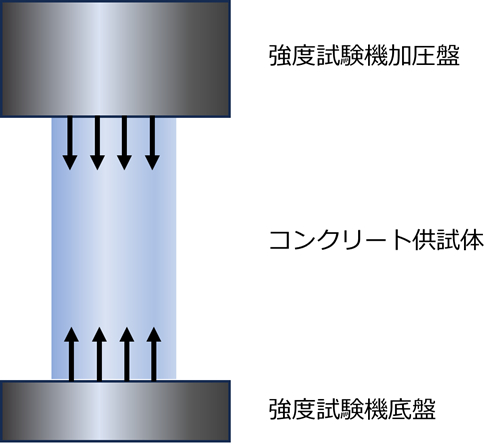

In [19]:
concrete_compressive_strength = fetch_ucirepo(id=165)
X = concrete_compressive_strength.data.features
y = concrete_compressive_strength.data.targets

display(X)
display(y)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


,Concrete compressive strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30
...,...
1025,44.28
1026,31.18
1027,23.70
1028,32.77


特徴量は以下の8つです．

- **Cement**：コンクリートに含まれるセメント量
  ($\mathrm{kg/m}^3$)．セメントはコンクリートの主成分であり，強度を決定する上で最も重要な材料の一つです．一般的にセメント量が増えるほど，圧縮強度は高まりますが，コストや収縮の増加にも注意が必要です．

- **Blast Furnace Slag**：高炉スラグの量
  ($\mathrm{kg/m}^3$)．高炉スラグはセメントの一部を置き換える補助材料として使用されます．強度の発現が遅い一方で，長期的な強度増加や耐久性の向上に寄与します．

- **Fly Ash**：フライアッシュ（石炭灰）の量
  ($\mathrm{kg/m}^3$)．フライアッシュもセメントを部分的に置き換える補助材料で，低コスト化や耐久性の改善に役立ちます．ただし，強度の発現は遅れる傾向があります．

- **Water**：混合に使用される水の量
  ($\mathrm{kg/m}^3$)．水はセメントと化学反応（硬化）を起こすために必要ですが，過剰な水は強度を低下させる原因となります．水とセメントの比率（水セメント比）は，圧縮強度に直接影響を与えます．

- **Superplasticizer**：高性能減水剤（スーパー可塑剤）の量
  ($\mathrm{kg/m}^3$)．減水剤は水の使用量を抑えつつ，作業性を向上させる添加剤です．これにより，強度を高めつつ施工性を維持できます．

- **Coarse Aggregate**：粗骨材（砕石等）の量
  ($\mathrm{kg/m}^3$)．粗骨材はコンクリートの骨組みを形成し，コンクリートの強度や剛性に寄与します．適切な骨材量が重要です．

- **Fine Aggregate**：細骨材（砂等）の量
  ($\mathrm{kg/m}^3$)．細骨材はコンクリートの充填性を向上させ，強度や耐久性のバランスを整える役割を果たします．

- **Age**：養生期間
  (日)．範囲は1～365日．コンクリートの強度は時間の経過とともに増加します（特に28日目までが顕著）．長期間の養生は強度のさらなる向上に繋がります．

ターゲット変数は次のものとします．

- **Concrete Compressive Strength**：コンクリートの圧縮強度 ($\mathrm{MPa}$)．コンクリートの耐荷性能を示す指標で，構造物の設計において最も重要なパラメータです．本項では，この圧縮強度をターゲット変数として予測します．

**Step 1**②はデータのチェックです．データを読み込んだら，まずデータに欠損値や異常値がないかチェックをします．

In [20]:
print("=== 1. Data Quality Check (Before Split) ===")

# 欠損値の確認
print("\n[Missing Values]")
display(X.isnull().sum())

# 基本統計量の確認（異常値・外れ値の候補を探す）
print("\n[Statistics - Features]")
display(X.describe())

print("\n[Statistics - Target]")
display(y.describe())

=== 1. Data Quality Check (Before Split) ===

[Missing Values]


,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0



[Statistics - Features]


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000



[Statistics - Target]


,Concrete compressive strength
count,1030.000000
mean,35.817961
std,16.705742
min,2.330000
25%,23.710000
50%,34.445000
75%,46.135000
max,82.600000


このデータについては，欠損値がないことが確認できました．また，min ，max の値や，業務知識をもとに異常値もないことが，確認できたとして，次に進みます．

**Step 1**③はデータの分割です．今回はハイパーパラメータの調整をグリッドサーチで実施する際に交差検証（クロスバリデーション）を行うのでデータセットを以下の2つに分割します．

- **トレーニングデータ**：モデルのトレーニングに使用します．検証データは交差検証でトレーニングごとに別々のデータセットをトレーニングデータの中から割り当てられます．

- **テストデータ**：最終的な評価に使用します．

次のコードでは．トレーニングデータ，テストデータを80%，20%に分けています．

In [21]:
from sklearn.model_selection import train_test_split

# 8:2 にデータを分割（トレーニング:80%，テスト:20%）
print("データをトレーニングデータ，テストデータに分割中...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 分割後のデータサイズを確認
print(f"トレーニングデータ: {X_train.shape}, {y_train.shape}")
print(f"テストデータ: {X_test.shape}, {y_test.shape}")

データをトレーニングデータ，テストデータに分割中...
トレーニングデータ: (824, 8), (824, 1)
テストデータ: (206, 8), (206, 1)


データ分割は，データを入手したらただちに行うべきです．後述するデータ理解のための分析手法（ペアプロットの作成，特徴量の分布確認，相関分析など）は，**データ分割後にトレーニングデータのみを対象として行う**ことが推奨されます．なぜなら，テストデータの情報を事前に知ることで，モデル構築や評価にバイアスが生じる可能性があるためです．トレーニングデータのみを使用することで，モデルの汎化性能を正確に評価でき，データ漏洩（データリーケージ，モデルの学習過程で本来未知であるべき情報が含まれてしまうこと）のリスクを回避できます．

**Step 1**④はペアプロットの作成です．ペアプロットは，特徴量間およびターゲット変数との関係性を直感的かつ総合的に把握できる，非常に強力なツールです．今回の場合，圧縮強度という重要なターゲット変数に対して，各材料成分や養生期間がどのような影響を与えるのか，あるいはそれらが互いにどのように関係しているのかを視覚的に確認することができます．

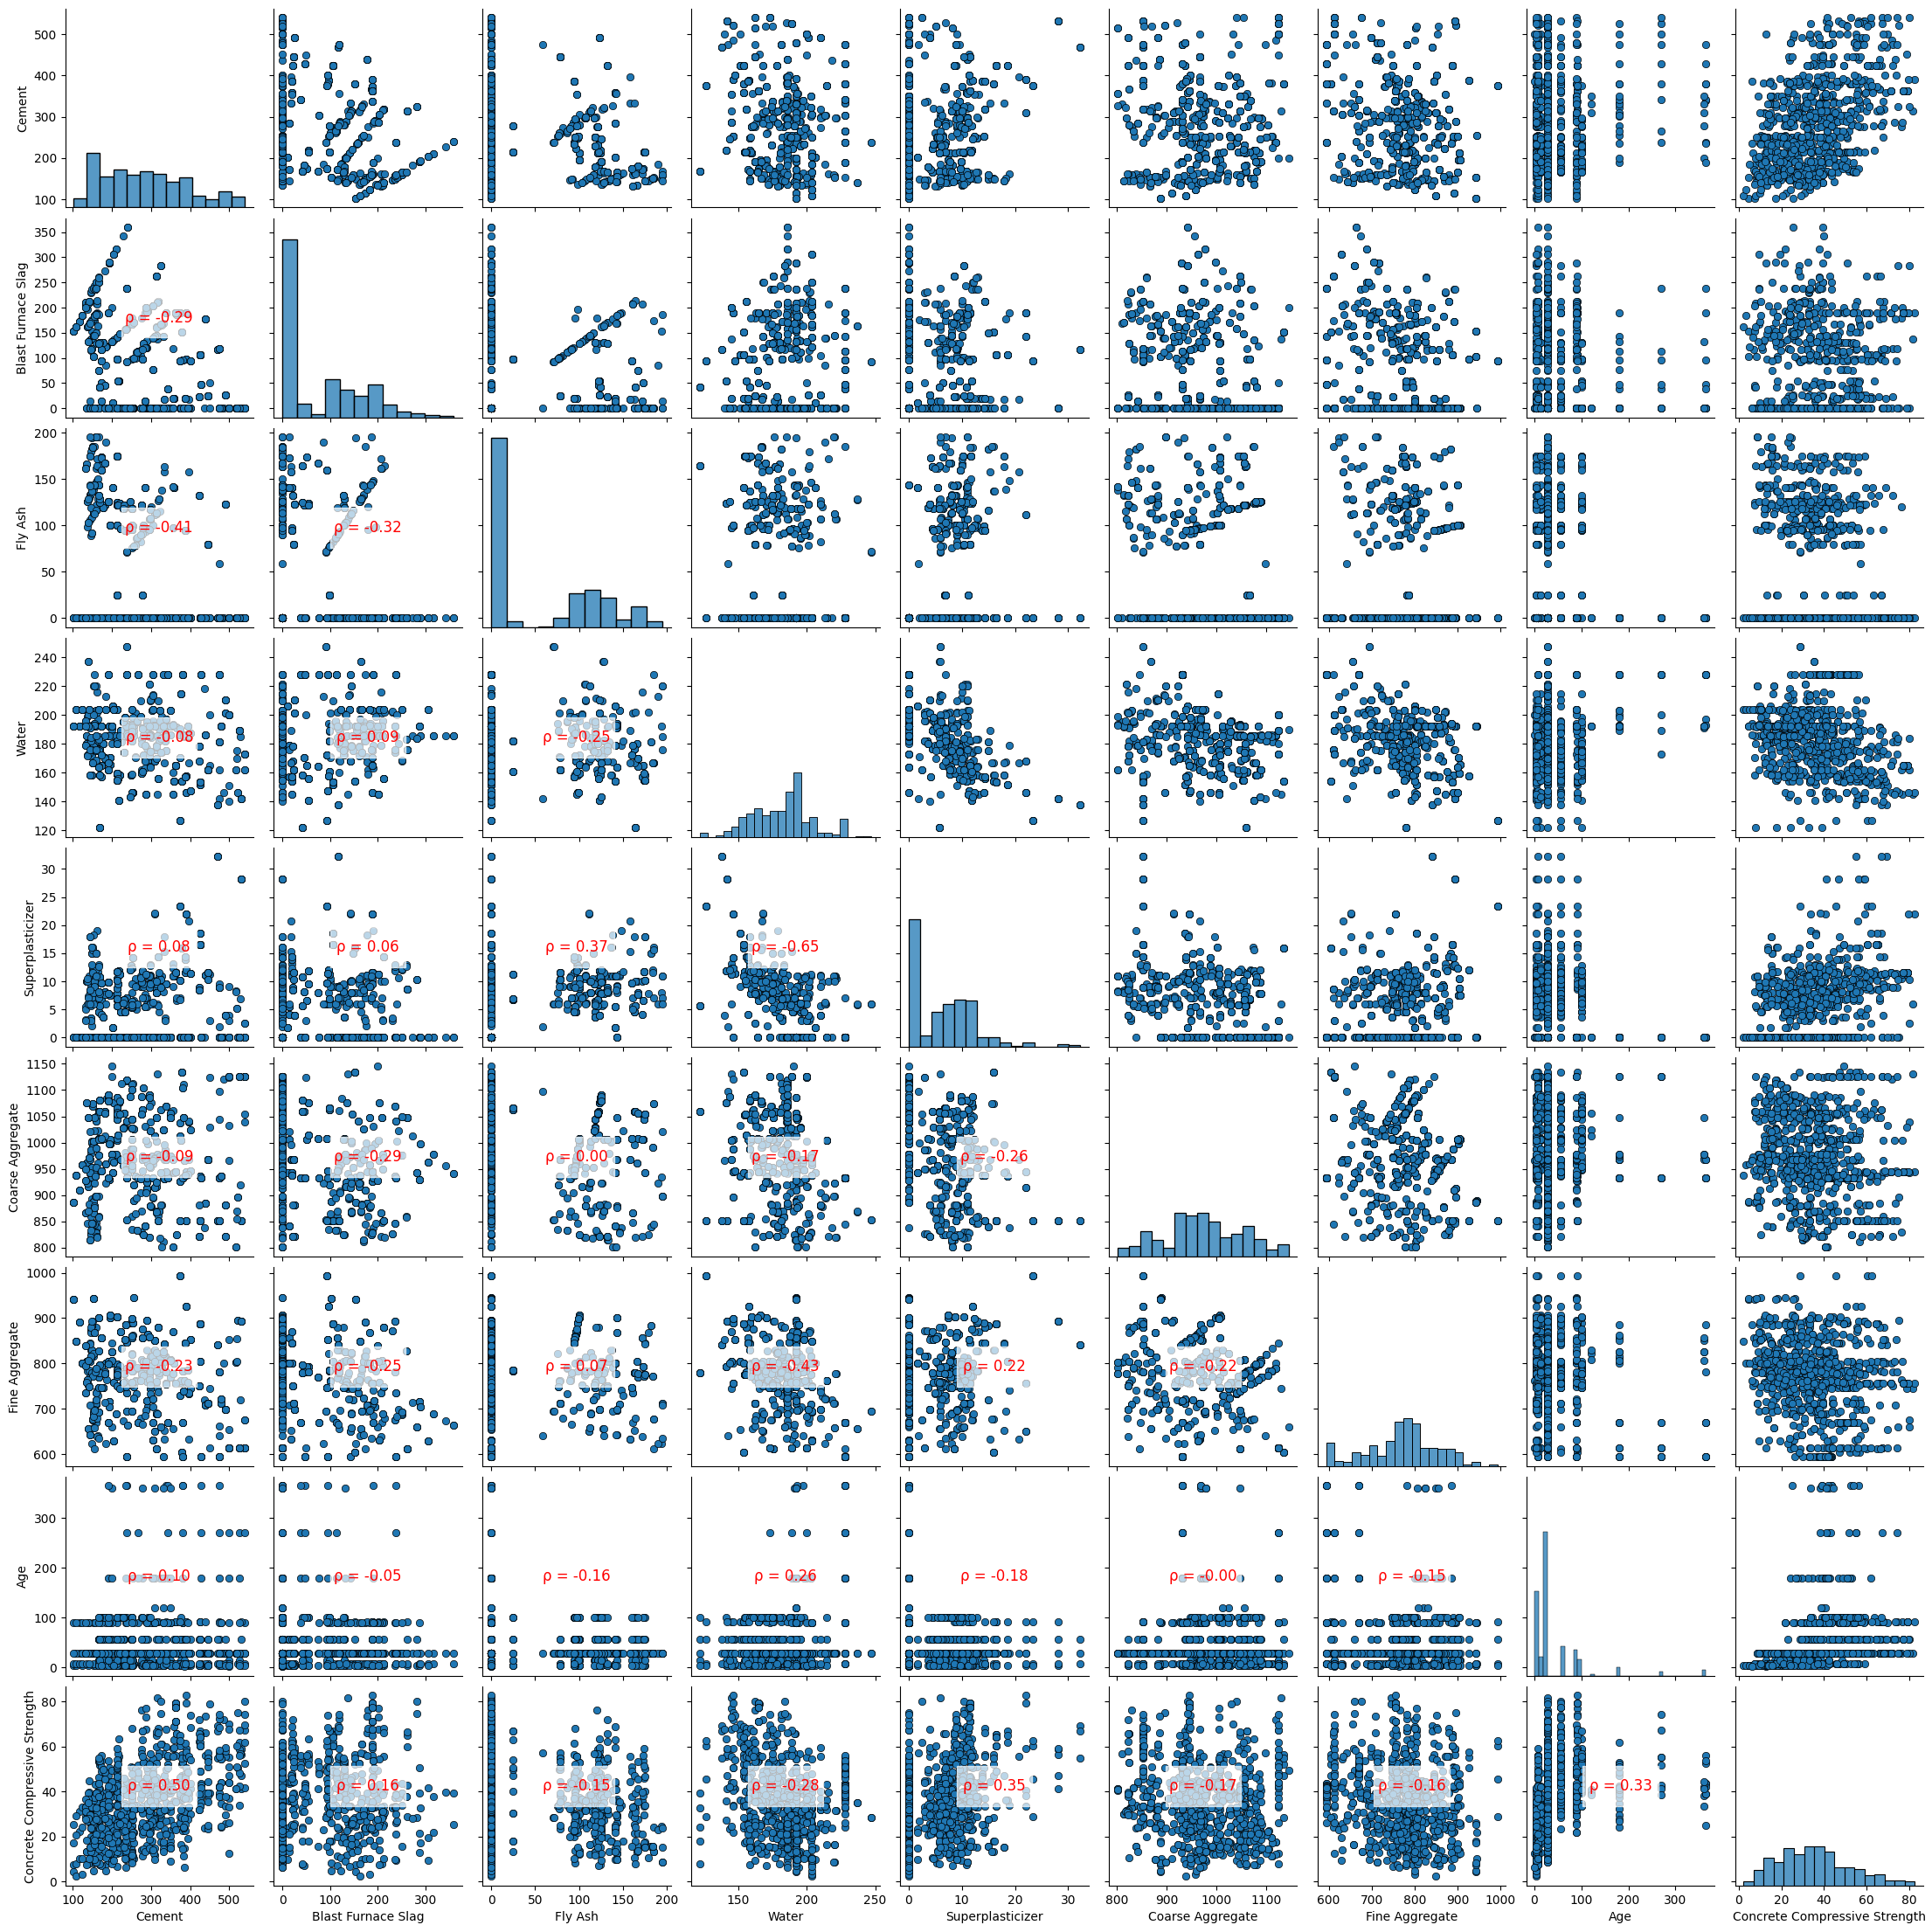

ペアプロットが ./決定木可視化/pairplotコンクリート_train.svg にSVG形式で保存されました．


In [22]:
# データフレームを統合（特徴量群とターゲット変数を結合）
data = X_train.copy()
data["Concrete Compressive Strength"] = y_train

# 保存先ディレクトリの作成
output_dir = './決定木可視化/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 相関係数をプロットに表示する関数
def corrplot(x, y, **kws):
    r, _ = pearsonr(x, y)  # ピアソンの相関係数を計算
    ax = plt.gca()

    # 矩形を追加 (背景の透明な枠)
    rect = Rectangle((0.3, 0.4), 0.4, 0.2, transform=ax.transAxes, color='white', alpha=0.7, zorder=1)
    ax.add_patch(rect)

    # 相関係数を矩形内に描画
    ax.annotate(f'ρ = {r:.2f}', xy=(0.5, 0.5), xycoords=ax.transAxes, ha='center', va='center', fontsize=12, color='red', zorder=2)

# ペアプロットの作成（白黒印刷対応：マーカーを使い分け）
pairplot = sns.pairplot(
    data,
    plot_kws={'edgecolor': 'black', 'linewidth': 0.5}  # 白黒印刷用にエッジを黒で強調
)
# グラフ上に相関係数を追加
pairplot.map_lower(corrplot)

# コンソールに表示
plt.show()

# SVG形式で保存
output_file = os.path.join(output_dir, 'pairplotコンクリート_train.svg')
pairplot.savefig(output_file, format='svg')

print(f"ペアプロットが {output_file} にSVG形式で保存されました．")

ペアプロットを作成したときには，既述のように２つの視点から考察します．1つはターゲット変数と特徴量の関係，もう１つは特徴量同士の関係です．また，対角線上には各特徴量のヒストグラムを表示でき，データそれぞれの分布を知るうえで役立ちます．

**ターゲット変数と特徴量の関係**

今回のデータでは，ターゲット変数と各特徴量の相関については強いとは言えません．相関係数を図中に表示してありますが，ターゲット変数の圧縮強度と最も大きな相関係数をもつのが Cement すなわちコンクリートに含まれるセメント量ですが，それでも相関係数は0.50です．ただ，相関係数が低い場合，特徴量とターゲットの間に非線形な関係が存在する可能性があります．回帰木は非線形な関係をモデル化するのに適しているため，相関係数が低くてもモデルの性能に大きな支障が出るとは限りません．特に，非線形な関係が存在する場合には，相関係数が低いことは必ずしも予測性能の低下を意味しないことが多いです．

**特徴量同士の関係**

今回のデータでは，特徴量同士の相関については絶対値が概ね0.5未満であり，モデルの特徴量重要度の解釈の難しさを引き起こす心配はなさそうです．

**各特徴量の分布**

対角線上には各特徴量のヒストグラムが表示されますので，これから特徴量それぞれの分布がわかります．Blast Furnace Slag，Fly Ash，Superplasticizer の3つの特徴量が，実際に多くのデータ点で0になっているのがわかります．

**Step 1**⑤はデータクレンジング欠損値が存在する場合は適切に補完します．また，外れ値があれば，それを処理します．今回は欠損値がないため，処理は不要です．

**Step 1**⑥はエンコーディングです．カテゴリ変数が含まれる場合，ラベルエンコーディングやワンホットエンコーディングを行う場合があります．今回は数値データのみであるため，この処理は不要です．

#### **■Step 2.回帰木の初期設定**

回帰木構築の初期設定をしたうえで，全てのトレーニングデータをまとめてルートノードに入れます．

scikit-learn の DecisionTreeRegressor による実装では，次のパラメータで分割基準を設定します．

- **評価基準**(criterion)：回帰木で分割を評価する基準です．デフォルトでは平均二乗誤差 (MSE) が使用され，分割ごとに予測誤差が小さくなるように分割が行われます．

回帰木の初期設定には，以下の主要なハイパーパラメータの設定が含まれます．

- **最大深さ**(max_depth)

- **最小分割サンプル数**(min_samples_split)

- **最小リーフサンプル数**(min_samples_leaf)

scikit-learn の DecisionTreeRegressor には他にも設定できるパラメータがありますが，今回は上記の3つのパラメータをグリッドサーチという方法で最適化します．

グリッドサーチの設定コードは次のようになります．


In [23]:
print("ハイパーパラメータチューニングを実施中...")
# ハイパーパラメータ候補
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

# モデルとGridSearchCVの設定
regressor = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=regressor,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

ハイパーパラメータチューニングを実施中...


GridSearchCV は，指定したハイパーパラメータの組み合わせに対して交差検証を行い，最適なパラメータを見つけ出します．デフォルトでは，refit=True に設定されており，**最適なパラメータで再度学習**します．つまり，grid_search.fit(X_train,y_train) を実行すると，最適なパラメータでトレーニングデータ全体に対してモデルが再学習され，grid_search.best_estimator_ にそのモデルが格納されます．

この動作により，最適なパラメータであらためてトレーニングを行う必要はありません．best_estimator_ を使用して，テストデータや新しいデータに対して予測を行うことができます．

#### **■Step 3. 子ノードの生成**

**Step 2**で設定したグリッドサーチをここで実行します．

In [24]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, None],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error')

#### **■Step 4. 終了条件を満たすまでの再帰的な木の成長**

**Step 3**で実行したグリッドサーチの結果から，**検証データに対して最も良い成績を示した回帰木モデル**を取り出します．また，その回帰木を作るときに使われた**パラメータの設定**も表示します．

In [25]:
best_model = grid_search.best_estimator_
print(f"最適パラメータ: {grid_search.best_params_}")

最適パラメータ: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


#### **■Step 5.回帰木の評価**

**Step 5**①はテストデータを使った評価です．最適化された回帰木の性能をテストデータを使って評価します．

テストデータで最終評価を実施中...
テストデータのRMSE: 7.07
テストデータのR2スコア: 0.81
予測結果を可視化中...


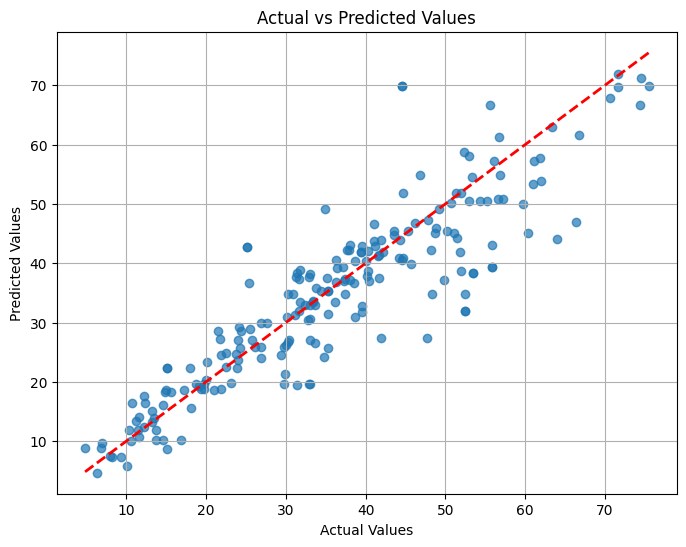

予測結果プロットが prediction_results.svg に保存されました．


In [26]:
print("テストデータで最終評価を実施中...")
y_test_pred = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
print(f"テストデータのRMSE: {test_rmse:.2f}")
print(f"テストデータのR2スコア: {test_r2:.2f}")

# 予測結果の可視化
# 実測値と予測値をプロット
print("予測結果を可視化中...")
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid(True)
result_plot_file = "prediction_results.svg"
plt.savefig(result_plot_file, format="svg")
plt.show()
print(f"予測結果プロットが {result_plot_file} に保存されました．")

**Step 5**②は特徴量の重要度の可視化です．最適なパラメータで再度学習した際の特徴量の重要度を可視化することは，データ解析結果を利用するうえで重要です．次のコードは，特徴量の重要度を棒グラフで表示します．


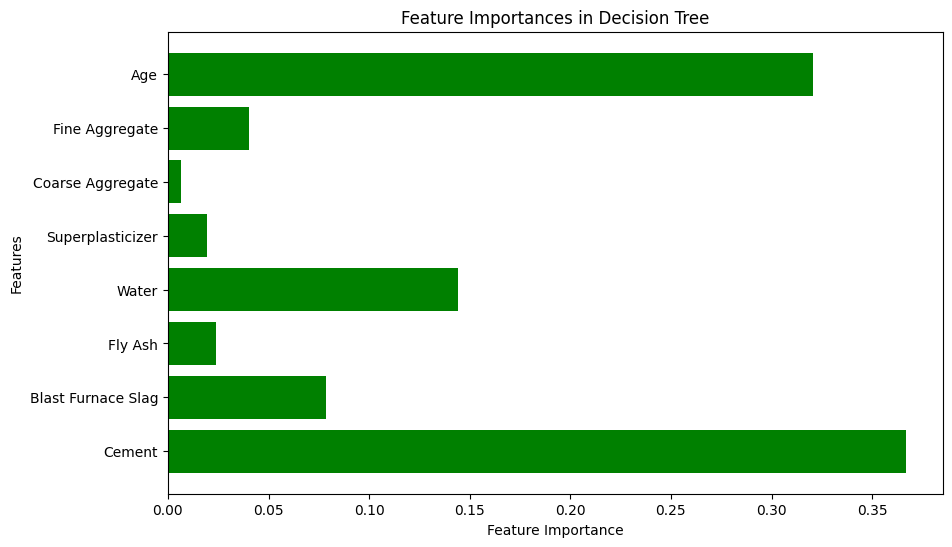

特徴量の重要度の図が ./決定木可視化/feature_importances.svg に保存されました．


In [27]:
import matplotlib.pyplot as plt
import os  # ディレクトリ操作のため

# 特徴量の重要度を取得
feature_importances = best_model.feature_importances_
feature_names = X_train.columns

# 保存先ディレクトリの作成
output_dir = "./決定木可視化"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 特徴量の重要度を可視化して保存
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances, color='green')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importances in Decision Tree")

# SVG形式で保存
output_file = os.path.join(output_dir, "feature_importances.svg")
plt.savefig(output_file, format="svg")

# コンソールに表示
plt.show()

print(f"特徴量の重要度の図が {output_file} に保存されました．")

**Step 5**③は回帰木の可視化です．best_model の回帰木を次のコードで可視化してみると，確かに，重要度上位の特徴量である Cement ，Age ，Water などを深さの浅いところで分割基準として使っていることがわかります．



決定木を可視化中（深さ3まで表示）...


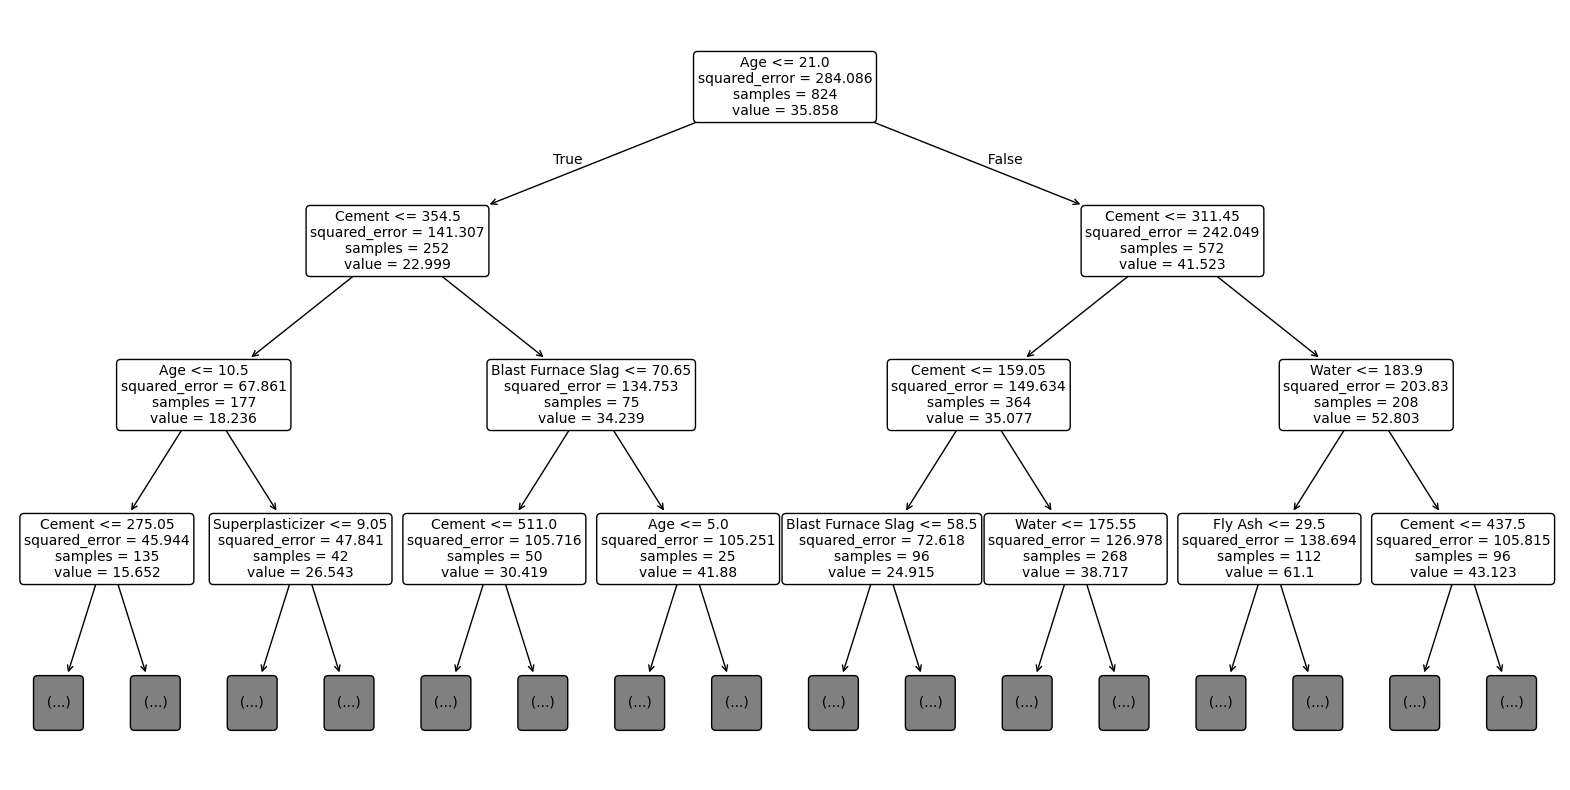

決定木の深さ3の可視化が decision_tree_visualization_depth3.svg に保存されました．


In [28]:
# 決定木の可視化（深さをmax_depthで制限）
max_depth = 3
print(f"決定木を可視化中（深さ{max_depth}まで表示）...")
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=X_train.columns,  # 特徴量名
    filled=False,
    rounded=True,
    fontsize=10,
    max_depth=max_depth  # 深さの制限
)

# SVG形式で保存
tree_plot_file = f"decision_tree_visualization_depth{max_depth}.svg"
plt.savefig(tree_plot_file, format="svg")
plt.show()

print(f"決定木の深さ{max_depth}の可視化が {tree_plot_file} に保存されました．")

best_model に含まれている決定木は，ここに表示しているよりもさらに深い構造をもっています．図では max_depth=3 によって深さを制限しており，最下段に表示されている箱は「この下にまだ分岐が続いている」ことを示す省略記号です．したがって，この箱は予測値を出すリーフノードではなく，表示を打ち切った位置を示すためのものです．